<a href="https://colab.research.google.com/github/pandeychetanya/HalloweenFlutter/blob/main/saccade_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocess eyetracking sessions (Colab tutorial)

Minimal walkthrough: calibrate Eyelink data and write `scanpaths_<datacode>.json`.

**Requirements on Drive** (under one folder, e.g. `MyDrive/steer_search_PD/steer_search_PD/`):

```
meta.yaml
<subject>/behav/<datacode>.json
<subject>/eye/<datacode>.edf
```

Image filenames are resolved from `config/steer-search.yaml` (installed with the package).

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pre-trial fixation anchor: False
Behavior path: /content/drive/MyDrive/steer_search_PD/steer-search-PD/p001/behav/250421_160302.json
EDF path: /content/drive/MyDrive/steer_search_PD/steer-search-PD/p001/eye/250421_160302.edf
messages columns: ['stime', 'message']
fixations columns: ['eye', 'start', 'end', 'gavx', 'gavy', 'type']
saccades columns: ['eye', 'stime', 'etime', 'sxp', 'syp', 'exp', 'eyp', 'pv']

FIXATIONS TABLE
['eye', 'start', 'end', 'gavx', 'gavy', 'type']


,eye,start,end,gavx,gavy,type
0,LEFT_EYE,0.007,0.072,805.599976,380.399994,fixation
1,LEFT_EYE,0.107,0.316,880.099976,330.799988,fixation
2,LEFT_EYE,0.361,0.435,773.599976,425.799988,fixation
3,LEFT_EYE,0.482,0.608,543.200012,436.600006,fixation
4,LEFT_EYE,0.656,0.787,309.299988,468.000000,fixation
5,LEFT_EYE,0.820,0.957,211.399994,451.600006,fixation
6,LEFT_EYE,1.013,1.033,617.599976,453.500000,fixation
7,LEFT_EYE,1.078,1.244,799.700012,448.600006,fixation
8,LEFT_EYE,1.309,1.336,946.799988,478.500000,fixation
9,LEFT_EYE,1.348,1.486,965.799988,440.799988,fixation



SACCADES TABLE
['eye', 'stime', 'etime', 'sxp', 'syp', 'exp', 'eyp', 'pv']


,eye,stime,etime,sxp,syp,exp,eyp,pv
0,LEFT_EYE,0.073,0.106,807.400024,375.299988,886.500000,352.100006,208.199997
1,LEFT_EYE,0.317,0.360,878.200012,334.899994,764.099976,427.500000,295.200012
2,LEFT_EYE,0.436,0.481,775.400024,429.000000,538.099976,436.100006,475.899994
3,LEFT_EYE,0.609,0.655,542.900024,434.899994,293.000000,478.399994,408.399994
4,LEFT_EYE,0.788,0.819,312.399994,465.000000,197.699997,456.700012,246.899994
5,LEFT_EYE,0.958,1.012,211.699997,454.700012,610.900024,455.600006,496.500000
6,LEFT_EYE,1.034,1.077,632.200012,452.899994,785.799988,447.799988,364.899994
7,LEFT_EYE,1.245,1.308,800.799988,450.200012,944.700012,470.100006,420.200012
8,LEFT_EYE,1.337,1.347,957.000000,475.100006,969.500000,466.200012,85.400002
9,LEFT_EYE,1.487,1.804,964.900024,417.700012,1014.500000,394.899994,381.700012



Fixation count: 1773
Saccade count: 1772
found 5 calibration sessions
Baseline calibration for prelim diagnosis...

Worst-case RMSE for each session in RMSE
[1.21626907587427, 17.298733673758214, 1.4479764001030389, 1.3131022692832908, 1.0701345418257333]
Using session : 4 as a baseline...


Starting baseline calibration...
Session 0, worst RMSE at position 5 is 1.824370216414362 < 2.0
...converged
Session 1, worst RMSE at position 0 is 21.733713259007715 > 2.0
...rejecting the data
Session 1, worst RMSE at position 8 is 1.6450321330866557 < 2.0
...converged
Session 2, worst RMSE at position 0 is 1.5715821994180323 < 2.0
...converged
Session 3, worst RMSE at position 15 is 1.8280543551744466 < 2.0
...converged
Session 4, worst RMSE at position 7 is 1.0701345418257333 < 2.0
...converged

Starting consensus calibration...
Session 0, worst RMSE at position 5 is 1.21626907587427 > 1.0
...rejecting the data
Session 0, worst RMSE at position 10 is 1.1079880728041738 > 1.0
...rejecting the d

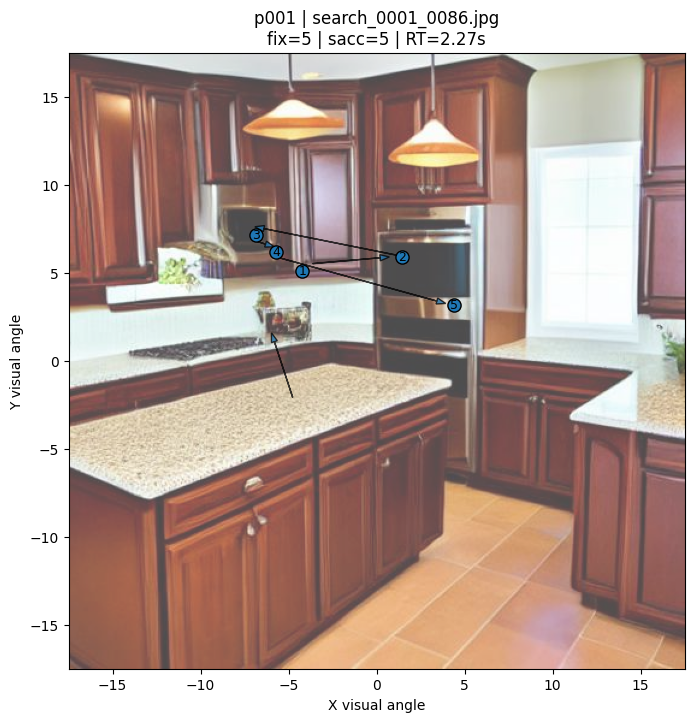


FIXATION COMPARISON SUMMARY
Total trials checked: 100
Matched trials: 100
Mismatched trials: 0
Missing trials: 0
Largest X difference: 3.552713678800501e-15
Largest Y difference: 5.329070518200751e-15

SUCCESS: Eyelinkio fixations match the existing scanpaths.json fixations (within floating-point precision).


In [ ]:
# =========================
# Raw EDF/behavior -> scanpaths JSON
# Includes fixations + saccades
# Uses eyelinkio instead of pyedfread
# =========================

!pip install -q eyelinkio pyyaml pandas
!pip install -q git+https://github.com/hyunwoogu/salience_bias.git

import json, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from google.colab import drive
import eyelinkio

from salience_bias.utils import psychopy
from salience_bias.utils.calibrate import Affine, consensus_calib, segment_trials
from salience_bias.utils.dataset import extract_info, load_array
from salience_bias.analyses.preprocess.core.image_map import load_imgn_exp_to_data

drive.mount("/content/drive")

#user settings

dataset_name = "steer-search"
subject = "p001"
datacode = "250421_160302"

data_root = Path("/content/drive/MyDrive/steer_search_PD/steer-search-PD")
interim_root = Path("/content/drive/MyDrive/salience_preprocess/interim") / dataset_name
interim_root.mkdir(parents=True, exist_ok=True)

calib_landmarks_list = [0, 25, 50, 75, 100]
calib_landmarks = dict(enumerate(calib_landmarks_list))
valid_calib_indices = list(calib_landmarks.keys())
valid_trial_indices = list(range(1, 101))

n_tail = 15
consensus_thres = 1.0
consensus_min_valid_targets = 9

imgn_exp_to_data = load_imgn_exp_to_data(dataset_name)

EMPTY_SACCADES = {
    "onset": [],
    "duration": [],
    "start_x_pix": [],
    "start_y_pix": [],
    "end_x_pix": [],
    "end_y_pix": [],
    "amplitude_pix": [],
    "start_x_deg": [],
    "start_y_deg": [],
    "end_x_deg": [],
    "end_y_deg": [],
    "amplitude_deg": [],
    "peak_velocity_raw": [],
    "count": 0,
}


# -------------------------
# Helper: read EDF
# -------------------------

def read_edf_with_eyelinkio(edf_path):
    edf = eyelinkio.read_edf(str(edf_path))
    dfs = edf.to_pandas()
    disc = dfs["discrete"]

    messages = disc["messages"].copy()
    fixations = disc["fixations"].copy()
    saccades = disc["saccades"].copy()

    if "message" not in messages.columns:
        possible = [
            c for c in messages.columns
            if c.lower() in ["message", "msg", "text"]
            or "message" in c.lower()
            or "text" in c.lower()
        ]
        if possible:
            messages = messages.rename(columns={possible[0]: "message"})
        else:
            raise RuntimeError(f"Could not find message column: {messages.columns.tolist()}")

    rename_map = {}
    for c in fixations.columns:
        cl = c.lower()
        if cl in ["start", "start_time", "stime"]:
            rename_map[c] = "start"
        elif cl in ["end", "end_time", "etime"]:
            rename_map[c] = "end"
        elif cl in ["duration", "dur"]:
            rename_map[c] = "duration"
        elif cl in ["gavx", "avg_x", "x", "x_avg", "mean_x", "axp"]:
            rename_map[c] = "gavx"
        elif cl in ["gavy", "avg_y", "y", "y_avg", "mean_y", "ayp"]:
            rename_map[c] = "gavy"

    fixations = fixations.rename(columns=rename_map)

    missing = [c for c in ["start", "gavx", "gavy"] if c not in fixations.columns]
    if missing:
        raise RuntimeError(f"Missing fixation columns: {missing}")

    fixations["type"] = "fixation"

    print("messages columns:", messages.columns.tolist())
    print("fixations columns:", fixations.columns.tolist())
    print("saccades columns:", saccades.columns.tolist())

    return dfs["samples"], fixations, messages, saccades


# -------------------------
# Helper: trial timing
# -------------------------



def parse_onset_info(messages):
    num_pattern = r"([-+]?\d*\.?\d+)"
    onset_info = {}

    for _, row in messages.iterrows():
        m = str(row["message"])
        msg_time = float(row["stime"])

        if not any(tag in m for tag in ("FIXATION_ONSET", "IMAGE_ONSET", "RESPONSE")):
            continue

        trial_match = re.search(r"TRIAL[ =](\d+)", m)
        trial = int(trial_match.group(1)) if trial_match else None
        if trial is None:
            continue

        onset_info.setdefault(trial, {})

        if "FIXATION_ONSET" in m:
            onset_info[trial].update({
                "ET_fix": msg_time,
                "PT_fix": extract_info(m, rf"PT={num_pattern}", float),
            })

        if "IMAGE_ONSET" in m:
            onset_info[trial].update({
                "ET_stim": msg_time,
                "PT_stim": extract_info(m, rf"PT={num_pattern}", float),
                "pre_stim": extract_info(m, rf"PRE={num_pattern}", float),
                "flip_stim": extract_info(m, rf"FLIP={num_pattern}", float),
                "post_stim": extract_info(m, rf"POST={num_pattern}", float),
                "id_stim": extract_info(m, r"STIM_ID=(\d+)", int),
            })

        if "RESPONSE" in m:
            onset_info[trial].update({
                "ET_resp": msg_time,
                "PT_resp": extract_info(m, rf"PT={num_pattern}", float),
                "key_resp": extract_info(m, r"KEY=([A-Za-z0-9_]+)"),
                "RT": extract_info(m, rf"RT={num_pattern}", float),
            })

    return onset_info


# -------------------------
# Helper: calibration
# -------------------------

def build_calib_params(data):
    calib_data = data["data"]["calibration_results"]
    print(f"found {len(calib_data)} calibration sessions")

    calib_data = [calib_data[i] for i in valid_calib_indices if i < len(calib_data)]
    ses_indices = np.arange(len(calib_data))

    positions_target = load_array([c["positions_target"] for c in calib_data])
    positions_eye = load_array(
        [np.array(c["positions_eye"])[..., -n_tail:] for c in calib_data]
    )

    positions_eye, valid_ses_bool = consensus_calib(
        positions_target,
        positions_eye,
        consensus_thres=consensus_thres,
        consensus_min_valid_targets=consensus_min_valid_targets,
        return_valid_consensus=True,
    )

    if sum(valid_ses_bool) == 0:
        raise RuntimeError("No valid calibration sessions found.")

    calib_landmarks_valid = {
        i: calib_landmarks[i]
        for i in ses_indices[valid_ses_bool]
    }

    segments_valid = segment_trials(
        calib_landmarks_valid,
        all_trials=valid_trial_indices
    )

    calib_params = {}

    for i_ses, t_ses, e_ses in zip(
        ses_indices[valid_ses_bool],
        positions_target[valid_ses_bool],
        positions_eye[valid_ses_bool],
    ):
        calib = Affine()
        calib.fit(t_ses, e_ses)
        calib_params[i_ses] = {
            "affine": calib,
            "trials": segments_valid[i_ses],
        }

    print("valid calibration session indices:", list(calib_params.keys()))

    return calib_params


# -------------------------
# Helper: extract one trial
# -------------------------

def extract_fixations_for_trial(events_fix, t_trial_stt, t_trial_end, affine):
    fix_trial = events_fix[
        (events_fix["start"].values > t_trial_stt) &
        (events_fix["start"].values <= t_trial_end)
    ]

    if len(fix_trial) == 0:
        return {
            "x": np.array([]),
            "y": np.array([]),
            "t": np.array([]),
        }

    gavx, gavy = psychopy.el2deg(
        fix_trial["gavx"].values,
        fix_trial["gavy"].values
    )

    gav = affine.transform(np.stack([gavx, gavy], axis=-1))

    return {
        "x": gav[:, 0],
        "y": gav[:, 1],
        "t": fix_trial["start"].values - t_trial_stt,
    }


def extract_saccades_for_trial(saccades, t_trial_stt, t_trial_end, affine):
    sac_trial = saccades[
        (saccades["stime"] > t_trial_stt) &
        (saccades["stime"] <= t_trial_end)
    ].copy()

    if len(sac_trial) == 0:
        return EMPTY_SACCADES.copy()

    onset = sac_trial["stime"].values - t_trial_stt
    duration = sac_trial["etime"].values - sac_trial["stime"].values

    sx_pix = sac_trial["sxp"].values.astype(float)
    sy_pix = sac_trial["syp"].values.astype(float)
    ex_pix = sac_trial["exp"].values.astype(float)
    ey_pix = sac_trial["eyp"].values.astype(float)

    amp_pix = np.sqrt((ex_pix - sx_pix) ** 2 + (ey_pix - sy_pix) ** 2)

    sx_deg, sy_deg = psychopy.el2deg(sx_pix, sy_pix)
    ex_deg, ey_deg = psychopy.el2deg(ex_pix, ey_pix)

    start_deg = affine.transform(np.stack([sx_deg, sy_deg], axis=-1))
    end_deg = affine.transform(np.stack([ex_deg, ey_deg], axis=-1))

    sx_deg_cal = start_deg[:, 0]
    sy_deg_cal = start_deg[:, 1]
    ex_deg_cal = end_deg[:, 0]
    ey_deg_cal = end_deg[:, 1]

    amp_deg = np.sqrt(
        (ex_deg_cal - sx_deg_cal) ** 2 +
        (ey_deg_cal - sy_deg_cal) ** 2
    )

    pv_raw = sac_trial["pv"].values.astype(float)

    return {
        "onset": np.round(onset, 4).tolist(),
        "duration": np.round(duration, 4).tolist(),

        "start_x_pix": np.round(sx_pix, 4).tolist(),
        "start_y_pix": np.round(sy_pix, 4).tolist(),
        "end_x_pix": np.round(ex_pix, 4).tolist(),
        "end_y_pix": np.round(ey_pix, 4).tolist(),
        "amplitude_pix": np.round(amp_pix, 4).tolist(),

        "start_x_deg": np.round(sx_deg_cal, 4).tolist(),
        "start_y_deg": np.round(sy_deg_cal, 4).tolist(),
        "end_x_deg": np.round(ex_deg_cal, 4).tolist(),
        "end_y_deg": np.round(ey_deg_cal, 4).tolist(),
        "amplitude_deg": np.round(amp_deg, 4).tolist(),

        "peak_velocity_raw": np.round(pv_raw, 4).tolist(),
        "count": int(len(sac_trial)),
    }


# -------------------------
# Load meta
# -------------------------

with open(data_root / "meta.yaml", "r") as f:
    meta = yaml.safe_load(f)

meta = {
    sub: {
        fname: m for fname, m in sessions.items()
        if not m.get("exclude", False) and m.get("experiment") == "search"
    }
    for sub, sessions in meta.items()
}


# -------------------------
# Load one session
# -------------------------

anchor = "anchor" in meta[subject][datacode]
print("pre-trial fixation anchor:", anchor)

behav_path = data_root / subject / "behav" / f"{datacode}.json"
edf_path = data_root / subject / "eye" / f"{datacode}.edf"

print("Behavior path:", behav_path)
print("EDF path:", edf_path)

with open(behav_path, "r") as f:
    data = json.load(f)

if anchor:
    if "fixation_positions" in data["data"]:
        anchor_positions = np.array(data["data"]["fixation_positions"]).T
    else:
        anchor_positions = np.zeros([len(valid_trial_indices), 2])
else:
    anchor_positions = [None] * len(valid_trial_indices)

samples, events, messages, saccades = read_edf_with_eyelinkio(edf_path)

print("\nFIXATIONS TABLE")
print(events.columns.tolist())
display(events.head(20))

print("\nSACCADES TABLE")
print(saccades.columns.tolist())
display(saccades.head(20))

print("\nFixation count:", len(events))
print("Saccade count:", len(saccades))



#printing tables


# -------------------------
# Fixations + saccades per trial
# -------------------------

calib_params = build_calib_params(data)

onset_info = parse_onset_info(messages)
print("trials with timing info:", len(onset_info))

events_fix = events[events["type"] == "fixation"].copy()

fixations_trials = {}
saccades_trials = {}

for i_ses, v_ses in calib_params.items():
    affine = v_ses["affine"]

    for trial_idx in v_ses["trials"]:
        if trial_idx not in onset_info:
            continue

        if "ET_stim" not in onset_info[trial_idx] or "ET_resp" not in onset_info[trial_idx]:
            continue

        t_trial_stt = onset_info[trial_idx]["ET_stim"]
        t_trial_end = onset_info[trial_idx]["ET_resp"]

        fixations_trials[trial_idx] = extract_fixations_for_trial(
            events_fix,
            t_trial_stt,
            t_trial_end,
            affine,
        )

        saccades_trials[trial_idx] = extract_saccades_for_trial(
            saccades,
            t_trial_stt,
            t_trial_end,
            affine,
        )


# -------------------------
# Build scanpaths
# -------------------------

scanpaths = []

for tr_idx in sorted(fixations_trials.keys()):
    i = int(tr_idx) - 1

    tr_rt = data["data"]["rt"][i]
    tr_imgp = data["data"]["images"][i]
    tr_choice = data["data"]["response"][i]
    tr_anchor = anchor_positions[i]

    blknum = int(meta[subject][datacode]["block"])
    imgn = int(Path(tr_imgp).stem)
    tgtn = meta[subject][datacode]["target"]

    tr_onset = fixations_trials[tr_idx]["t"]
    tr_T = np.round(np.diff(np.concatenate([tr_onset, [tr_rt]])), 4)

    scanpath = {
        "block": blknum,
        "trial": int(tr_idx),
        "subject": subject,
        "image": imgn_exp_to_data[(blknum, imgn, tgtn)],
        "target": tgtn,

        "X": fixations_trials[tr_idx]["x"].tolist(),
        "Y": fixations_trials[tr_idx]["y"].tolist(),
        "T": tr_T.tolist(),
        "onset": tr_onset.tolist(),
        "length": len(tr_onset),

        "choice": {0: "present", 1: "absent"}[tr_choice],
        "RT": tr_rt,

        "saccades": saccades_trials.get(int(tr_idx), EMPTY_SACCADES.copy()),
    }

    if tr_anchor is not None:
        scanpath["anchor"] = tr_anchor.tolist()

    scanpaths.append(scanpath)


# -------------------------
# Save output
# -------------------------

out_dir = interim_root / subject
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"scanpaths_{datacode}.json"

with open(out_path, "w") as f:
    json.dump(scanpaths, f, indent=2)

print(f"saved {len(scanpaths)} trials to {out_path}")

if scanpaths:
    lengths = [s["length"] for s in scanpaths]
    sacc_counts = [s["saccades"]["count"] for s in scanpaths]

    print(
        "example trial:",
        scanpaths[0]["trial"],
        scanpaths[0]["image"],
        "n_fix=",
        scanpaths[0]["length"],
        "n_sacc=",
        scanpaths[0]["saccades"]["count"],
    )

    print("Min fixations:", min(lengths))
    print("Max fixations:", max(lengths))
    print("Mean fixations:", np.mean(lengths))
    print("Trials with zero fixations:", sum(l == 0 for l in lengths))

    print("Min saccades:", min(sacc_counts))
    print("Max saccades:", max(sacc_counts))
    print("Mean saccades:", np.mean(sacc_counts))
    print("Trials with zero saccades:", sum(c == 0 for c in sacc_counts))

    sp = scanpaths[0]
    print("\nExample saccades object:")
    print(json.dumps(sp["saccades"], indent=2)[:1200])

    amps = []
    pvs = []

    for tr in scanpaths:
        amps.extend(tr["saccades"]["amplitude_deg"])
        pvs.extend(tr["saccades"]["peak_velocity_raw"])

    if amps and pvs:
        print("Amplitude range:", min(amps), max(amps))
        print("PV range:", min(pvs), max(pvs))
else:
    print("No scanpaths saved.")


# ============================================================
# Visualize fixations + saccades for chosen subject + image
# Overlay on stimulus image
# ============================================================

def plot_scanpath_on_image(target_subject, target_image):
    scanpaths_path = interim_root / "scanpaths_with_saccades.json"

    with open(scanpaths_path, "r") as f:
        all_scanpaths = json.load(f)

    matches = [
        t for t in all_scanpaths
        if t["subject"] == target_subject
        and t["image"] == target_image
    ]

    if len(matches) == 0:
        raise ValueError(f"No match found for subject={target_subject}, image={target_image}")

    trial_data = matches[0]

    print("Subject:", trial_data["subject"])
    print("Image:", trial_data["image"])
    print("Trial:", trial_data["trial"])
    print("Target:", trial_data["target"])
    print("Choice:", trial_data["choice"])
    print("RT:", trial_data["RT"])
    print("Fixations:", trial_data["length"])
    print("Saccades:", trial_data["saccades"]["count"])

    search_roots = [
        data_root,
        Path("/content/drive/MyDrive/steer_search_PD"),
        Path("/content/drive/MyDrive"),
    ]

    img_path = None

    for root in search_roots:
        hits = list(root.rglob(target_image))
        if hits:
            img_path = hits[0]
            break

    if img_path is None:
        raise FileNotFoundError(
            f"Could not find {target_image}. Try checking exact image filename."
        )

    print("Using image file:", img_path)

    img = Image.open(img_path)

    XMIN, XMAX = -17.5, 17.5
    YMIN, YMAX = -17.5, 17.5
    EXTENT = [XMIN, XMAX, YMIN, YMAX]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, extent=EXTENT, origin="upper", alpha=0.7)

    sac = trial_data["saccades"]

    for i in range(sac["count"]):
        sx = sac["start_x_deg"][i]
        sy = sac["start_y_deg"][i]
        ex = sac["end_x_deg"][i]
        ey = sac["end_y_deg"][i]

        ax.arrow(
            sx,
            sy,
            ex - sx,
            ey - sy,
            length_includes_head=True,
            head_width=0.35,
            alpha=0.75,
        )

    xs = trial_data["X"]
    ys = trial_data["Y"]

    ax.scatter(xs, ys, s=90, edgecolors="black", zorder=3)

    for i, (x, y) in enumerate(zip(xs, ys), start=1):
        ax.text(
            x,
            y,
            str(i),
            fontsize=9,
            ha="center",
            va="center",
            zorder=4,
        )


    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

    ax.set_xlabel("X visual angle")
    ax.set_ylabel("Y visual angle")

    ax.set_title(
        f"{target_subject} | {target_image}\n"
        f"fix={trial_data['length']} | sacc={sac['count']} | RT={trial_data['RT']:.2f}s"
    )

    ax.grid(False)
    plt.show()


# -------------------------
# Choose what to visualize
# -------------------------

plot_scanpath_on_image(
    target_subject="p001",
    target_image="search_0001_0086.jpg",
)

# ============================================================
# Compare eyelinkio fixations vs existing scanpaths.json
# Expected: X/Y fixation points should match
# ============================================================

existing_scanpaths_path = Path(
    "/content/drive/MyDrive/steer_search_PD/scanpaths.json"
)

with open(existing_scanpaths_path, "r") as f:
    existing_scanpaths = json.load(f)

existing_lookup = {
    (sp["subject"], sp["trial"], sp["image"]): sp
    for sp in existing_scanpaths
}

total_trials = 0
matched_trials = 0
mismatched_trials = 0
missing_trials = 0

max_x_diff_global = 0
max_y_diff_global = 0

for new_sp in scanpaths:

    key = (
        new_sp["subject"],
        new_sp["trial"],
        new_sp["image"],
    )

    total_trials += 1

    if key not in existing_lookup:
        print("MISSING:", key)
        missing_trials += 1
        continue

    old_sp = existing_lookup[key]

    eyelink_x = np.array(new_sp["X"])
    eyelink_y = np.array(new_sp["Y"])

    json_x = np.array(old_sp["X"])
    json_y = np.array(old_sp["Y"])

    if len(eyelink_x) != len(json_x):
        print("\nLENGTH MISMATCH")
        print(key)
        print("JSON length:", len(json_x))
        print("Eyelink length:", len(eyelink_x))
        mismatched_trials += 1
        continue

    x_diff = np.max(np.abs(eyelink_x - json_x))
    y_diff = np.max(np.abs(eyelink_y - json_y))

    max_x_diff_global = max(max_x_diff_global, x_diff)
    max_y_diff_global = max(max_y_diff_global, y_diff)

    x_match = np.allclose(
        eyelink_x,
        json_x,
        atol=1e-12,
        rtol=0,
    )

    y_match = np.allclose(
        eyelink_y,
        json_y,
        atol=1e-12,
        rtol=0,
    )

    if x_match and y_match:
        matched_trials += 1
    else:
        mismatched_trials += 1

        print("\nMISMATCH")
        print("subject/trial/image:", key)
        print("max X diff:", x_diff)
        print("max Y diff:", y_diff)

        print("JSON X:", json_x)
        print("EYELINK X:", eyelink_x)

        print("JSON Y:", json_y)
        print("EYELINK Y:", eyelink_y)

print("\n===================================")
print("FIXATION COMPARISON SUMMARY")
print("===================================")
print("Total trials checked:", total_trials)
print("Matched trials:", matched_trials)
print("Mismatched trials:", mismatched_trials)
print("Missing trials:", missing_trials)
print("Largest X difference:", max_x_diff_global)
print("Largest Y difference:", max_y_diff_global)

if mismatched_trials == 0:
    print(
        "\nSUCCESS: Eyelinkio fixations match the "
        "existing scanpaths.json fixations "
        "(within floating-point precision)."
    )

In [ ]:
# # ============================================================
# # Generate combined scanpaths_with_saccades.json across all trials
# # ============================================================

# def process_session(subject, datacode):
#     behav_path = data_root / subject / "behav" / f"{datacode}.json"
#     edf_path = data_root / subject / "eye" / f"{datacode}.edf"

#     if not behav_path.exists() or not edf_path.exists():
#         print("Missing file:", subject, datacode)
#         return []

#     with open(behav_path, "r") as f:
#         data = json.load(f)

#     anchor = "anchor" in meta[subject][datacode]

#     if anchor:
#         if "fixation_positions" in data["data"]:
#             anchor_positions = np.array(data["data"]["fixation_positions"]).T
#         else:
#             anchor_positions = np.zeros([len(valid_trial_indices), 2])
#     else:
#         anchor_positions = [None] * len(valid_trial_indices)

#     samples, events, messages, saccades = read_edf_with_eyelinkio(edf_path)

#     # -------------------------
#     # Calibration
#     # -------------------------

#     calib_data = data["data"]["calibration_results"]
#     calib_data = [calib_data[i] for i in valid_calib_indices if i < len(calib_data)]

#     ses_indices = np.arange(len(calib_data))

#     positions_target = load_array([c["positions_target"] for c in calib_data])
#     positions_eye = load_array(
#         [np.array(c["positions_eye"])[..., -n_tail:] for c in calib_data]
#     )

#     positions_eye, valid_ses_bool = consensus_calib(
#         positions_target,
#         positions_eye,
#         consensus_thres=consensus_thres,
#         consensus_min_valid_targets=consensus_min_valid_targets,
#         return_valid_consensus=True,
#     )

#     if sum(valid_ses_bool) == 0:
#         print("No valid calibration:", subject, datacode)
#         return []

#     calib_landmarks_valid = {
#         i: calib_landmarks[i]
#         for i in ses_indices[valid_ses_bool]
#     }

#     segments_valid = segment_trials(
#         calib_landmarks_valid,
#         all_trials=valid_trial_indices
#     )

#     calib_params = {}

#     for i_ses, t_ses, e_ses in zip(
#         ses_indices[valid_ses_bool],
#         positions_target[valid_ses_bool],
#         positions_eye[valid_ses_bool],
#     ):
#         calib = Affine()
#         calib.fit(t_ses, e_ses)
#         calib_params[i_ses] = {
#             "affine": calib,
#             "trials": segments_valid[i_ses],
#         }

#     # -------------------------
#     # Parse trial timing
#     # -------------------------

#     num_pattern = r"([-+]?\d*\.?\d+)"
#     onset_info = {}

#     for _, row in messages.iterrows():
#         m = str(row["message"])
#         msg_time = float(row["stime"])

#         if not any(tag in m for tag in ("FIXATION_ONSET", "IMAGE_ONSET", "RESPONSE")):
#             continue

#         trial_match = re.search(r"TRIAL[ =](\d+)", m)
#         trial = int(trial_match.group(1)) if trial_match else None

#         if trial is None:
#             continue

#         onset_info.setdefault(trial, {})

#         if "FIXATION_ONSET" in m:
#             onset_info[trial].update({
#                 "ET_fix": msg_time,
#                 "PT_fix": extract_info(m, rf"PT={num_pattern}", float),
#             })

#         if "IMAGE_ONSET" in m:
#             onset_info[trial].update({
#                 "ET_stim": msg_time,
#                 "PT_stim": extract_info(m, rf"PT={num_pattern}", float),
#                 "pre_stim": extract_info(m, rf"PRE={num_pattern}", float),
#                 "flip_stim": extract_info(m, rf"FLIP={num_pattern}", float),
#                 "post_stim": extract_info(m, rf"POST={num_pattern}", float),
#                 "id_stim": extract_info(m, r"STIM_ID=(\d+)", int),
#             })

#         if "RESPONSE" in m:
#             onset_info[trial].update({
#                 "ET_resp": msg_time,
#                 "PT_resp": extract_info(m, rf"PT={num_pattern}", float),
#                 "key_resp": extract_info(m, r"KEY=([A-Za-z0-9_]+)"),
#                 "RT": extract_info(m, rf"RT={num_pattern}", float),
#             })

#     events_fix = events[events["type"] == "fixation"].copy()
#     t_stt = events_fix["start"].values

#     fixations_trials = {}
#     saccades_trials = {}

#     empty_saccades = {
#         "onset": [],
#         "duration": [],

#         "start_x_pix": [],
#         "start_y_pix": [],
#         "end_x_pix": [],
#         "end_y_pix": [],
#         "amplitude_pix": [],

#         "start_x_deg": [],
#         "start_y_deg": [],
#         "end_x_deg": [],
#         "end_y_deg": [],
#         "amplitude_deg": [],

#         "peak_velocity_raw": [],
#         "count": 0,
#     }

#     # -------------------------
#     # Fixations + saccades per trial
#     # -------------------------

#     for i_ses, v_ses in calib_params.items():
#         affine = v_ses["affine"]

#         for trial_idx in v_ses["trials"]:
#             if trial_idx not in onset_info:
#                 continue

#             if "ET_stim" not in onset_info[trial_idx] or "ET_resp" not in onset_info[trial_idx]:
#                 continue

#             t_trial_stt = onset_info[trial_idx]["ET_stim"]
#             t_trial_end = onset_info[trial_idx]["ET_resp"]

#             # Fixations
#             fix_trial = events_fix[
#                 (t_stt > t_trial_stt) &
#                 (t_stt <= t_trial_end)
#             ]

#             if len(fix_trial) == 0:
#                 gavx_trial = np.array([])
#                 gavy_trial = np.array([])
#                 onset_time = np.array([])
#             else:
#                 gavx_trial, gavy_trial = psychopy.el2deg(
#                     fix_trial["gavx"].values,
#                     fix_trial["gavy"].values
#                 )

#                 gav_trial = affine.transform(
#                     np.stack([gavx_trial, gavy_trial], axis=-1)
#                 )

#                 gavx_trial = gav_trial[:, 0]
#                 gavy_trial = gav_trial[:, 1]
#                 onset_time = fix_trial["start"].values - t_trial_stt

#             fixations_trials[trial_idx] = {
#                 "x": gavx_trial,
#                 "y": gavy_trial,
#                 "t": onset_time,
#             }

#             # Saccades
#             sac_trial = saccades[
#                 (saccades["stime"] > t_trial_stt) &
#                 (saccades["stime"] <= t_trial_end)
#             ].copy()

#             if len(sac_trial) == 0:
#                 saccades_trials[trial_idx] = empty_saccades.copy()
#             else:
#                 sac_onset = sac_trial["stime"].values - t_trial_stt
#                 sac_duration = sac_trial["etime"].values - sac_trial["stime"].values

#                 sx_pix = sac_trial["sxp"].values.astype(float)
#                 sy_pix = sac_trial["syp"].values.astype(float)
#                 ex_pix = sac_trial["exp"].values.astype(float)
#                 ey_pix = sac_trial["eyp"].values.astype(float)

#                 amp_pix = np.sqrt(
#                     (ex_pix - sx_pix) ** 2 +
#                     (ey_pix - sy_pix) ** 2
#                 )

#                 sx_deg, sy_deg = psychopy.el2deg(sx_pix, sy_pix)
#                 ex_deg, ey_deg = psychopy.el2deg(ex_pix, ey_pix)

#                 start_deg = affine.transform(
#                     np.stack([sx_deg, sy_deg], axis=-1)
#                 )
#                 end_deg = affine.transform(
#                     np.stack([ex_deg, ey_deg], axis=-1)
#                 )

#                 sx_deg_cal = start_deg[:, 0]
#                 sy_deg_cal = start_deg[:, 1]
#                 ex_deg_cal = end_deg[:, 0]
#                 ey_deg_cal = end_deg[:, 1]

#                 amp_deg = np.sqrt(
#                     (ex_deg_cal - sx_deg_cal) ** 2 +
#                     (ey_deg_cal - sy_deg_cal) ** 2
#                 )

#                 pv_raw = sac_trial["pv"].values.astype(float)

#                 saccades_trials[trial_idx] = {
#                     "onset": np.round(sac_onset, 4).tolist(),
#                     "duration": np.round(sac_duration, 4).tolist(),

#                     "start_x_pix": np.round(sx_pix, 4).tolist(),
#                     "start_y_pix": np.round(sy_pix, 4).tolist(),
#                     "end_x_pix": np.round(ex_pix, 4).tolist(),
#                     "end_y_pix": np.round(ey_pix, 4).tolist(),
#                     "amplitude_pix": np.round(amp_pix, 4).tolist(),

#                     "start_x_deg": np.round(sx_deg_cal, 4).tolist(),
#                     "start_y_deg": np.round(sy_deg_cal, 4).tolist(),
#                     "end_x_deg": np.round(ex_deg_cal, 4).tolist(),
#                     "end_y_deg": np.round(ey_deg_cal, 4).tolist(),
#                     "amplitude_deg": np.round(amp_deg, 4).tolist(),

#                     "peak_velocity_raw": np.round(pv_raw, 4).tolist(),
#                     "count": int(len(sac_trial)),
#                 }

#     # -------------------------
#     # Build scanpaths for this session
#     # -------------------------

#     session_scanpaths = []

#     for tr_idx in sorted(fixations_trials.keys()):
#         i = int(tr_idx) - 1

#         tr_rt = data["data"]["rt"][i]
#         tr_imgp = data["data"]["images"][i]
#         tr_choice = data["data"]["response"][i]
#         tr_anchor = anchor_positions[i]

#         blknum = int(meta[subject][datacode]["block"])
#         imgn = int(Path(tr_imgp).stem)
#         tgtn = meta[subject][datacode]["target"]

#         tr_onset = fixations_trials[tr_idx]["t"]
#         tr_T = np.round(np.diff(np.concatenate([tr_onset, [tr_rt]])), 4)

#         scanpath = {
#             "block": blknum,
#             "trial": int(tr_idx),
#             "subject": subject,
#             "image": imgn_exp_to_data[(blknum, imgn, tgtn)],
#             "target": tgtn,

#             "X": fixations_trials[tr_idx]["x"].tolist(),
#             "Y": fixations_trials[tr_idx]["y"].tolist(),
#             "T": tr_T.tolist(),
#             "onset": tr_onset.tolist(),
#             "length": len(tr_onset),

#             "choice": {0: "present", 1: "absent"}[tr_choice],
#             "RT": tr_rt,

#             "saccades": saccades_trials.get(int(tr_idx), empty_saccades.copy()),
#         }

#         if tr_anchor is not None:
#             scanpath["anchor"] = tr_anchor.tolist()

#         session_scanpaths.append(scanpath)

#     return session_scanpaths


# # ============================================================
# # Loop across all subjects and datacodes
# # ============================================================

# all_scanpaths = []
# failed_sessions = []

# for sub in sorted(meta.keys()):
#     for dc in sorted(meta[sub].keys()):
#         print("\nProcessing:", sub, dc)

#         try:
#             session_scanpaths = process_session(sub, dc)
#             all_scanpaths.extend(session_scanpaths)

#             print(
#                 "Added",
#                 len(session_scanpaths),
#                 "trials | total so far:",
#                 len(all_scanpaths)
#             )

#         except Exception as e:
#             print("FAILED:", sub, dc, repr(e))
#             failed_sessions.append({
#                 "subject": sub,
#                 "datacode": dc,
#                 "error": repr(e),
#             })


# # ============================================================
# # Save combined output
# # ============================================================

# combined_path = interim_root / "scanpaths_with_saccades.json"

# with open(combined_path, "w") as f:
#     json.dump(all_scanpaths, f, indent=2)

# print("\nDONE")
# print("Saved combined file:", combined_path)
# print("Total trials:", len(all_scanpaths))
# print("Failed sessions:", len(failed_sessions))

# if failed_sessions:
#     failed_path = interim_root / "failed_sessions_with_saccades.json"
#     with open(failed_path, "w") as f:
#         json.dump(failed_sessions, f, indent=2)
#     print("Failed session log:", failed_path)

# subjects = sorted(set(t["subject"] for t in all_scanpaths))
# print("Total subjects:", len(subjects))
# print("First subjects:", subjects[:10])
# print("Last subjects:", subjects[-10:])

# if all_scanpaths:
#     lengths = [t["length"] for t in all_scanpaths]
#     sacc_counts = [t["saccades"]["count"] for t in all_scanpaths]

#     print("Mean fixations:", np.mean(lengths))
#     print("Trials with zero fixations:", sum(x == 0 for x in lengths))

#     print("Mean saccades:", np.mean(sacc_counts))
#     print("Trials with zero saccades:", sum(x == 0 for x in sacc_counts))

#     amps = []
#     pvs = []

#     for t in all_scanpaths:
#         amps.extend(t["saccades"]["amplitude_deg"])
#         pvs.extend(t["saccades"]["peak_velocity_raw"])

#     if amps and pvs:
#         print("Amplitude range:", min(amps), max(amps))
#         print("PV range:", min(pvs), max(pvs))

Streaming output truncated to the last 5000 lines.
Session 1, worst RMSE at position 8 is 1.950054996598221 < 2.0
...converged
Session 2, worst RMSE at position 13 is 2.925456468924513 > 2.0
...rejecting the data
Session 2, worst RMSE at position 6 is 2.191239061097676 > 2.0
...rejecting the data
Session 2, worst RMSE at position 3 is 1.1964267695864814 < 2.0
...converged
Session 3, worst RMSE at position 0 is 5.154658588738191 > 2.0
...rejecting the data
Session 3, worst RMSE at position 5 is 1.0291487272251918 < 2.0
...converged
Session 4, worst RMSE at position 16 is 0.8249734021390422 < 2.0
...converged

Starting consensus calibration...
Session 0, worst RMSE at position 3 is 1.069850966706572 > 1.0
...rejecting the data
Session 0, worst RMSE at position 14 is 0.7757054961923721 < 1.0
...converged
Session 1, worst RMSE at position 8 is 1.6393515673593382 > 1.0
...rejecting the data
Session 1, worst RMSE at position 13 is 1.679232282101406 > 1.0
...rejecting the data
Session 1, wors